In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../Datasets/clean_retail_sales_dataset.csv')
df

,Unnamed: 0,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...,...
995,995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [3]:
df["Date"] = pd.to_datetime(df["Date"],errors="coerce")

Top-selling products

In [4]:
top_selling_products =(
    df
    .groupby("Product Category", as_index=False)
    .agg(top_selling=("Quantity", "sum"))
    .sort_values("top_selling", ascending=False)
    .head(5)
)

top_selling_products

,Product Category,top_selling
1,Clothing,894
2,Electronics,849
0,Beauty,771


Revenue by product

In [5]:
product_revenue = (
    df
    .groupby("Product Category", as_index=False)
    .agg(revenue=("Total Amount", "sum"))
    .sort_values("revenue", ascending=False)
    .head(5)
)

product_revenue["revenue"] = product_revenue["revenue"].round(2)

product_revenue

,Product Category,revenue
2,Electronics,156905
1,Clothing,155580
0,Beauty,143515


Monthly sales trends

In [ ]:
df["month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

monthly_sales =(
    df
    .groupby("month", as_index=False)
    .agg(monthly_sales=("Total Amount", "sum"))
    .sort_values("monthly_sales", ascending=False)
    .head(5)
)

monthly_sales["monthly_sales"] = monthly_sales["monthly_sales"].round(2)

monthly_sales

,month,monthly_sales
4,2023-05-01,53150
9,2023-10-01,46580
11,2023-12-01,44690
1,2023-02-01,44060
7,2023-08-01,36960


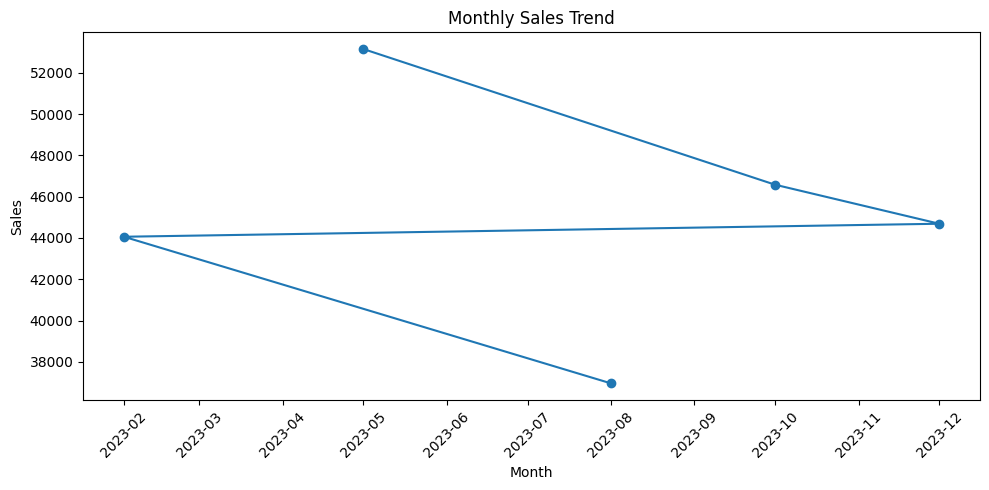

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["monthly_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top customers by spending

In [11]:
top_customer =(
    df
    .groupby(["Customer ID","Gender","Age"], as_index=False,dropna=False)
    .agg(total_spending=("Total Amount","sum"))
    .sort_values("total_spending", ascending=False)
)

top_customer["total_spending"] = top_customer["total_spending"].round(2)

top_customer

,Customer ID,Gender,Age,total_spending
946,CUST946,Male,62,2000
626,CUST626,Female,26,2000
634,CUST634,Male,60,2000
773,CUST773,Male,25,2000
420,CUST420,Female,22,2000
...,...,...,...,...
486,CUST486,Female,35,25
979,CUST979,Female,19,25
989,CUST989,Female,44,25
955,CUST955,Male,58,25


Which age group buys the most?

Average order value and quantity by product